In [1]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import mitsuba as mi
import drjit as dr
import torch
import numpy as np
import math
import time
from contextlib import contextmanager

mi.set_variant('cuda_ad_rgb')
scene = mi.load_file("assets/sphere_scene.xml", integrator='direct')
params = mi.traverse(scene)

@contextmanager
def timer(name = ""):
    start = time.time()
    try:
        yield
    finally:
        end = time.time()
        print(f"{name} Time elapsed: {end - start:.3f} seconds")

In [2]:
# randomly generate some cameras
cameras = []
cameras.append({'to_world': mi.Transform4f.look_at(origin=[0.6,0.2,0], target=[0,0,0], up=[0,1,0]), 'x_fov': 60, 'lightpos':[0.7,0.1,0]})

def set_camera(cam1):
    params['PerspectiveCamera.x_fov'] = cam1['x_fov']
    params['PerspectiveCamera.to_world'] = cam1['to_world']
    params['PointLight.position'] = cam1['lightpos']
set_camera(cameras[0])
params.update()
I_GT = mi.render(scene, params, spp=64).torch()

param_keys = ['wood_olive_wood_olive_basecolor.data', 'wood_olive_wood_olive_roughness.data']
tex_shape = params[param_keys[0]].shape[:2]

In [3]:
mi.util.convert_to_bitmap(I_GT)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [4]:
import random

@dr.wrap_ad(source='torch', target='drjit')
def render(tex0, tex1, *, spp=1, seed=None):
    params[param_keys[0]] = tex0
    params[param_keys[1]] = tex1
    params.update()
    if seed is None:
        seed = random.randint(0, 2147483646)
    return mi.render(scene, params, spp=spp, seed=seed, seed_grad=seed+1)

In [5]:
def prior(x, k=1000, thres=0.02):
    return k*(thres-x).clamp(min=0.0)**2 + k*(x-1+thres).clamp(min=0.0)**2
    
def U(theta, *, sigma=0.05):
    I = render(theta[...,0:3], theta[...,3:4])
    return ((I - I_GT).square()/(2*sigma**2) + math.log(sigma*math.sqrt(2*math.pi))).sum() + prior(theta).sum()

In [13]:
# Gradient descent
x1 = torch.rand((*tex_shape, 4), device='cuda', requires_grad=True)
opt = torch.optim.Adam([x1], lr=0.01)
for it in tqdm(range(100)):
    U(x1).backward()
    opt.step()
    opt.zero_grad()
    x1.data.clamp_(min=0, max=1)
mi.util.convert_to_bitmap(x1[256:512,32:288,0:3]) # custom

  0%|          | 0/100 [00:00<?, ?it/s]

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]

In [9]:
def SVGD(n=40, n_iter=100):
    x = torch.rand((n, *tex_shape, 4), device='cuda', requires_grad=True)
    opt = torch.optim.Adam([x], lr=0.01)
    for it in tqdm(range(n_iter)):
        # render to get gradient dU/dx
        for i in range(n):
            U(x[i]).backward()
        with torch.no_grad():
            # perform kernel update by blocks of rows to reduce memory usage
            row_block_size = 16
            for r0 in range(0, x.shape[1], row_block_size):
                r1 = min(r0+row_block_size, x.shape[1])
                # current block of rows: [r0, r1)
                pairwise_diff = x[:,r0:r1,...].unsqueeze(1) - x[:,r0:r1,...].unsqueeze(0)
                pairwise_dist2 = torch.sum(pairwise_diff ** 2, dim=-1)
                # per-texel bandwidth using median heuristic
                h = torch.quantile(pairwise_dist2.flatten(end_dim=1), q=0.5, dim=0) / math.log(n)
                rbf = torch.exp(-pairwise_dist2 / h)
                # update gradient
                x.grad[:,r0:r1,...] = 1/n * (torch.einsum('ijab,jabk->iabk', rbf, x.grad[:,r0:r1,...]) -2 * (pairwise_diff * rbf.unsqueeze(-1)).sum(axis=1) / h.unsqueeze(-1))
        # adagrad update
        opt.step()
        opt.zero_grad()
        x.data.clamp_(min=0, max=1)
    return x

In [10]:
x = SVGD()

  0%|          | 0/100 [00:00<?, ?it/s]

In [17]:
mi.util.convert_to_bitmap(x.mean(axis=0))

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [234]:
(x==0).sum() + (x==1).sum()

tensor(2072, device='cuda:0')

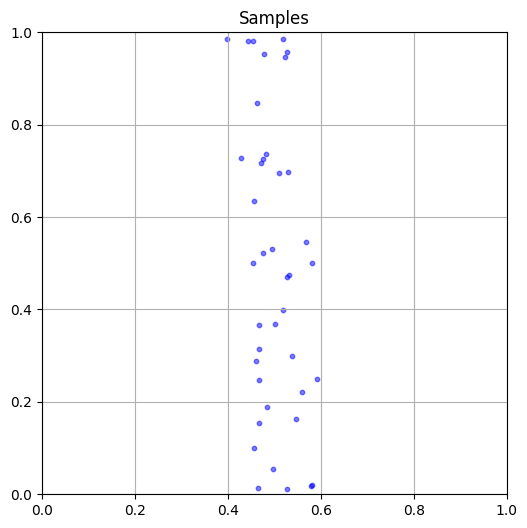

In [30]:
def plot_samples(samples, opacity=0.5, title='Samples', savefile=None):
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], c='blue', s=10, alpha=opacity)
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()
plot_samples(x[:,400,150,1::2].detach().cpu())

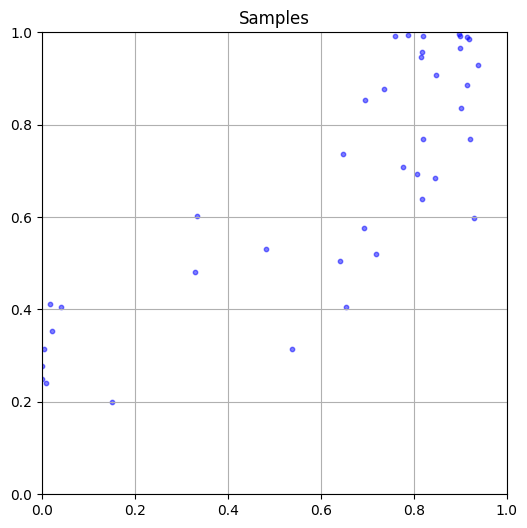

In [31]:
plot_samples(x[:,372,185,1::2].detach().cpu())

C:\Users\bilibili\AppData\Local\Temp\ipykernel_33100\3382389939.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


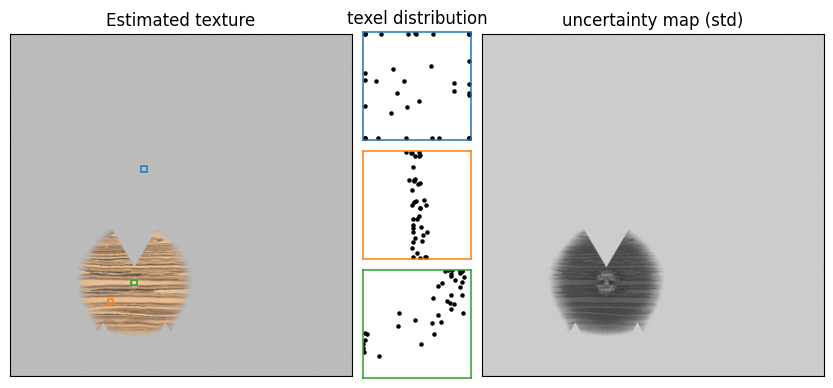

In [64]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

def plot_texture_samples(x, coords):
    img = mi.util.convert_to_bitmap(x.mean(axis=0))
    img2 = mi.util.convert_to_bitmap(x.var(axis=0).sum(axis=-1))
    # img2 = x.var(axis=0).sum(axis=-1).sqrt().cpu().detach()
    n = len(coords)
    
    fig = plt.figure(figsize=(10.5, 4.5))
    gs = gridspec.GridSpec(n, 3, width_ratios=[3, 1, 3], wspace=0.03, hspace=0.1)
    cmap = plt.get_cmap('tab10')

    # Left subplot
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(img)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_title("Estimated texture")

    # Right subplot
    ax2 = fig.add_subplot(gs[:, 2])
    ax2.imshow(img2)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("uncertainty map (std)")

    for row in range(n):
        a,b = coords[row]
        rectsize = 8
        rx = b - rectsize/2
        ry = a - rectsize/2
        rect = patches.Rectangle((rx, ry), rectsize, rectsize, linewidth=1.1, edgecolor=cmap(row), facecolor='none')
        ax1.add_patch(rect)
        
        ax = fig.add_subplot(gs[row, 1])
        pts = x[:,a,b,1::2].cpu().detach()
        ax.scatter(pts[:,0], pts[:,1], s=5, c='black')
        for spine in ['left', 'right', 'top', 'bottom']:
            ax.spines[spine].set_color(cmap(row))
            ax.spines[spine].set_linewidth(1.1) 
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('square')
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)

        if row == 0:
            ax.set_title("texel distribution")

    # Adjust the layout
    plt.tight_layout()
    plt.show()

plot_texture_samples(x, [(202,200),(400,150),(372,185)])

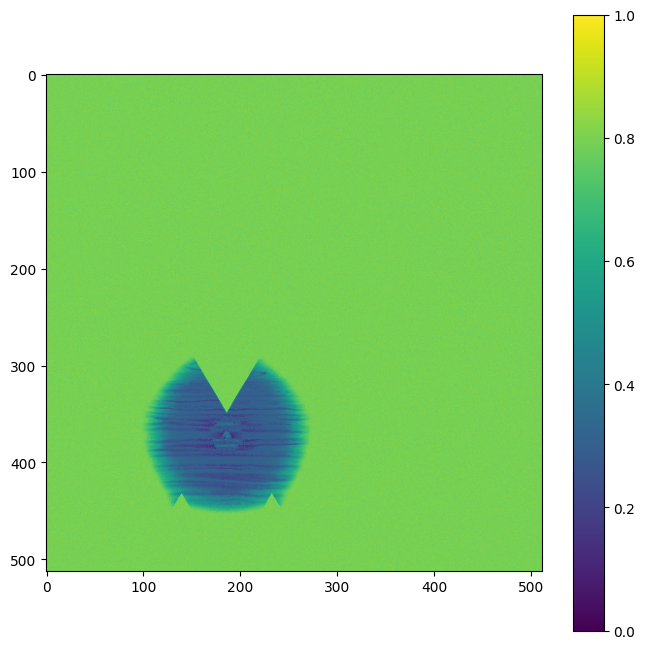

In [177]:
plt.figure(figsize=(8,8))
plt.imshow(x.detach().var(dim=0).sum(axis=-1).sqrt().cpu(), vmin=0, vmax=1)
plt.colorbar()

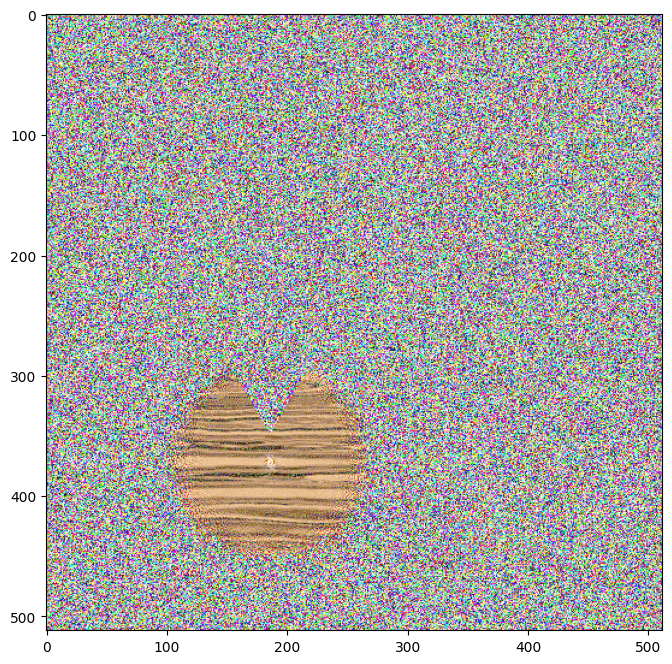

In [26]:
plt.figure(figsize=(8,8))
plt.imshow(mi.util.convert_to_bitmap(x[0]))
# plt.imshow(x[0,...,0:3].detach().cpu()**0.454)
# plt.imshow(x.mean(axis=0).cpu().detach()**0.454)

In [22]:
mi.util.convert_to_bitmap(x[0])

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

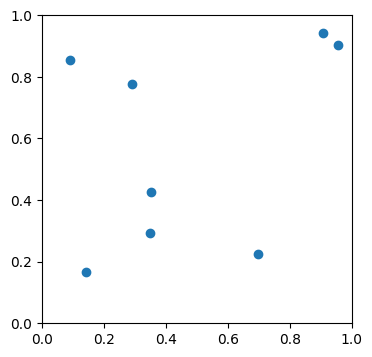

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Number of points
n = 10

# Create initial data
x = np.random.rand(n)
y = np.random.rand(n)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(4, 4))
sc = ax.scatter(x, y)

def update(frame):
    # Move points randomly
    global x
    global y
    x += np.random.randn(n) * 0.01
    y += np.random.randn(n) * 0.01
    sc.set_offsets(np.c_[x, y])
    return sc,

ani = FuncAnimation(fig, update, frames=200, blit=True, interval=17, repeat=True)

plt.xlim(0, 1)
plt.ylim(0, 1)

# Use the to_jshtml method to generate an HTML representation
HTML(ani.to_jshtml())


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Constants
N_PARTICLES = 100  # Number of particles
N_STEPS = 200  # Number of animation steps
DELTA = 0.1  # Step size

# Initialize positions of the particles
positions = np.random.rand(N_PARTICLES, 2)

# Create the figure and scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(positions[:, 0], positions[:, 1], s=10)

# Set the plot limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Brownian Motion of Particles")

# Define the update function for the animation
def update(frame):
    global positions
    # Update particle positions using Brownian motion
    positions += DELTA * (np.random.rand(N_PARTICLES, 2) - 0.5)
    # Boundary conditions
    positions = np.clip(positions, 0, 1)
    scatter.set_offsets(positions)
    return scatter,

# Create the animation
ani = FuncAnimation(fig, update, frames=N_STEPS, blit=True, interval=50)

# Convert the animation to HTML5 video format for displaying in the notebook
HTML(ani.to_jshtml())
